# Croco, In-situ and altimetry data
This week, we will manipulate some of these three type of data. 
In this notebook, we open the different types of datasets and compute some basic figures with each of them to get a preview of their possibilities

In [1]:
import xarray  as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

# CROCO model
### Documentation: https://croco-ocean.gitlabpages.inria.fr/croco_doc/index.html

Simulation give many variables as outputs, up to the choice of the user. This file has 36 data variables available every three days over the yeat 2005.

In [4]:
croco_dir = './Datasets/croco/'
croco = xr.open_dataset(croco_dir+"croco_his.nc")
# "fix" the time variable
croco["time"] = pd.date_range(start="2005-01-01", periods=120, freq="3D")
croco

<xarray.Dataset> Size: 188MB
Dimensions:     (s_rho: 32, s_w: 33, eta_rho: 44, xi_rho: 43, time: 120,
                 auxil: 4, xi_u: 42, eta_v: 43)
Coordinates: (12/13)
  * s_rho       (s_rho) float32 128B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float32 132B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
  * eta_rho     (eta_rho) float32 176B 1.0 2.0 3.0 4.0 ... 41.0 42.0 43.0 44.0
  * xi_rho      (xi_rho) float32 172B 1.0 2.0 3.0 4.0 ... 40.0 41.0 42.0 43.0
    lon_rho     (eta_rho, xi_rho) float32 8kB ...
    lat_rho     (eta_rho, xi_rho) float32 8kB ...
    ...          ...
    lat_v       (eta_v, xi_rho) float32 7kB ...
  * time        (time) datetime64[us] 960B 2005-01-01 2005-01-04 ... 2005-12-24
  * xi_u        (xi_u) float32 168B 1.5 2.5 3.5 4.5 5.5 ... 39.5 40.5 41.5 42.5
    lon_u       (eta_rho, xi_u) float32 7kB ...
    lat_u       (eta_rho, xi_u) float32 7kB ...
  * eta_v       (eta_v) float32 172B 1.5 2.5 3.5 4.5 5.5 ... 40.5 41.5 42.5 43.5
Dimensions without coordinates: auxil
Data variables: (12/36)
    spherical   |S1 1B ...
    xl          float32 4B ...
    el          float32 4B ...
    Vtransform  float32 4B ...
    Cs_rho      (s_rho) float32 128B ...
    Cs_w        (s_w) float32 132B ...
    ...          ...
    shflux      (time, eta_rho, xi_rho) float32 908kB ...
    swflux      (time, eta_rho, xi_rho) float32 908kB ...
    radsw       (time, eta_rho, xi_rho) float32 908kB ...
    shflx_rlw   (time, eta_rho, xi_rho) float32 908kB ...
    shflx_lat   (time, eta_rho, xi_rho) float32 908kB ...
    shflx_sen   (time, eta_rho, xi_rho) float32 908kB ...
Attributes: (12/55)
    type:           CROCO history file
    title:          BENGUELA TEST MODEL
    date:           
    rst_file:       outputs/croco_rst.nc
    his_file:       outputs/croco_his.nc
    avg_file:       outputs/croco_avg.nc
    ...             ...
    rho0_expl:      Mean density used in Boussinesq approximation
    rho0_units:     kilogram meter-3
    gamma2:         1.0
    gamma2_expl:    Slipperiness parameter
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL BENGUELA_LR OBC_EAST OBC_WEST OBC_NORTH OBC_SOUT...

### Mask
Simulation outputs typically have a land mask saying where there is water or not.

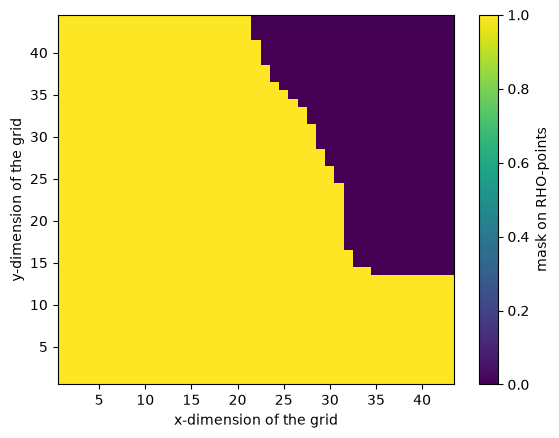

In [5]:
croco.mask_rho.plot()

### Temperature field for a given depth
We use **where(croco.mask_rho!=0)** to apply the mask to our plot.

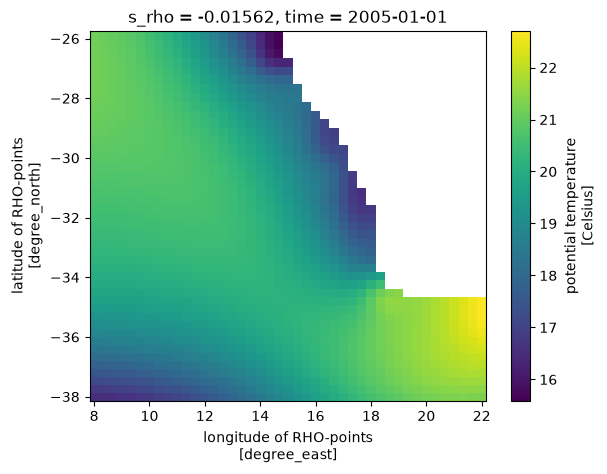

In [12]:
croco.temp.isel(time=0, s_rho=-1).where(croco.mask_rho!=0).plot(
    x='lon_rho', 
    y='lat_rho', 
)

### Temperature time series
we cam use a for loop to indicate the times we keep for the plots.

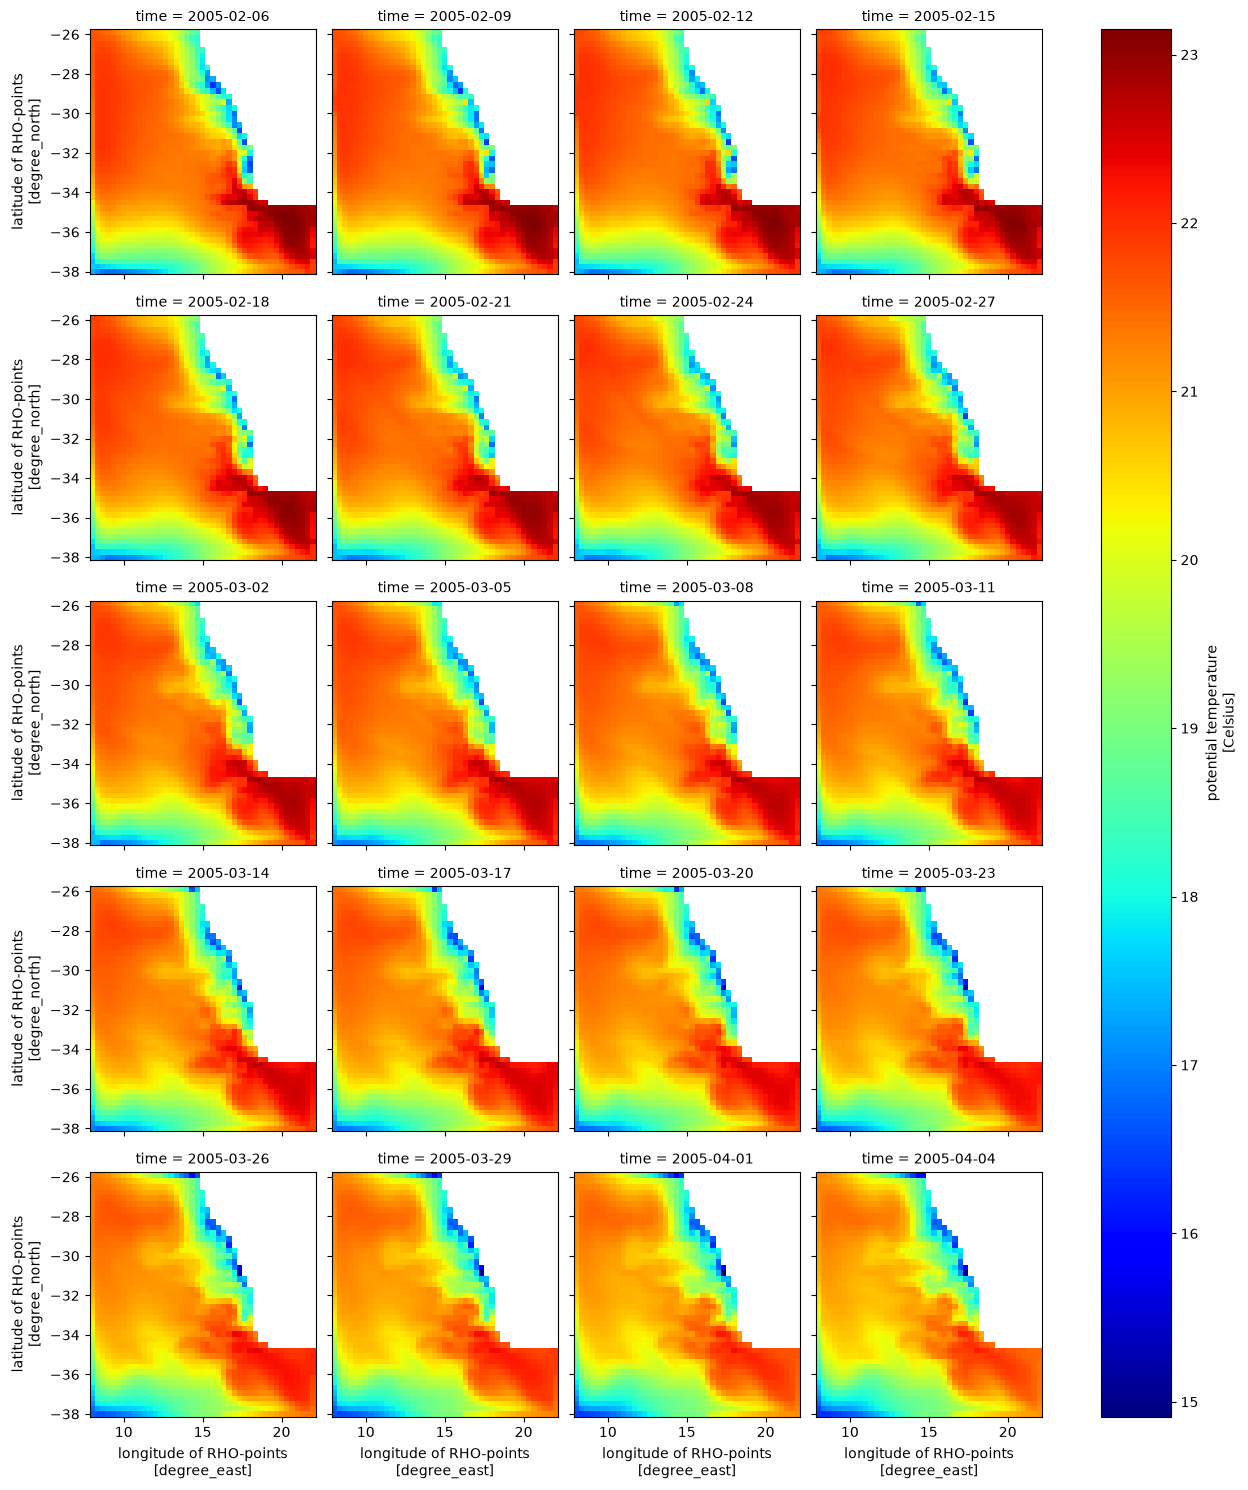

In [11]:
croco.temp.isel(time=[int(x) for x in np.arange(12,32)]).where(croco.mask_rho!=0).isel(s_rho=-1)\
    .plot(x='lon_rho',y='lat_rho',col='time',col_wrap=4,cmap='jet')

### Add physical depth to the dataset coordinates
Doc: https://croco-ocean.gitlabpages.inria.fr/croco_doc/model/model.grid.html#vertical-grid-parameters

In [13]:
croco = croco.assign_coords(
    z_rho = croco.zeta + (croco.zeta + croco.h) * ((croco.hc * croco.s_rho + croco.h * croco.Cs_rho) / (croco.hc + croco.h))
)

### Temperature profile
For a given point in horizontal space at a given time, we can plot the temperature as function of depth

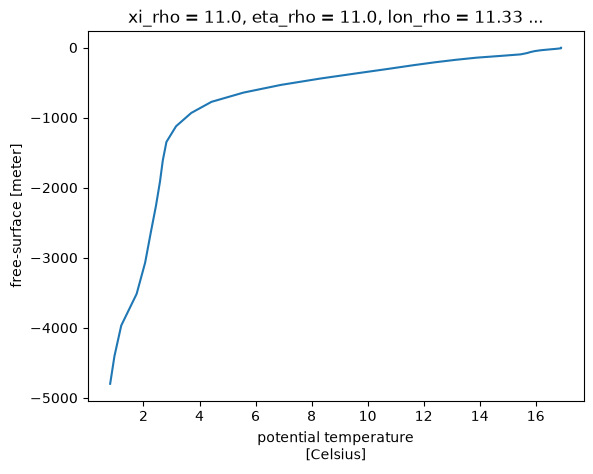

In [14]:
croco.temp.isel(xi_rho=10,eta_rho=10,time =100).plot(y='z_rho')

### Placing this point on the map

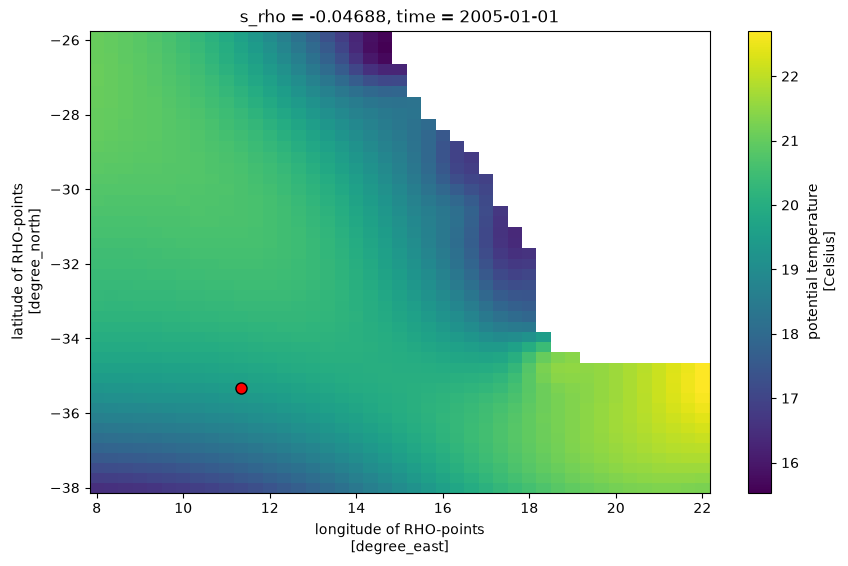

In [15]:
# Convert eta_rho and xi_rho to lat,lon
target_lon = croco.lon_rho.isel(eta_rho=10, xi_rho=10).values
target_lat = croco.lat_rho.isel(eta_rho=10, xi_rho=10).values

fig, ax = plt.subplots(figsize=(10, 6))

#Plot temperature
croco.temp.isel(time=0, s_rho=30).where(croco.mask_rho != 0).plot(
    ax=ax, x="lon_rho", y="lat_rho"
)

#Plot the point
ax.plot(
    target_lon,
    target_lat,
    marker="o",
    color="red",
    markersize=8,
    markeredgecolor="black",

)

plt.show()

### And on the globe Orthographic projection

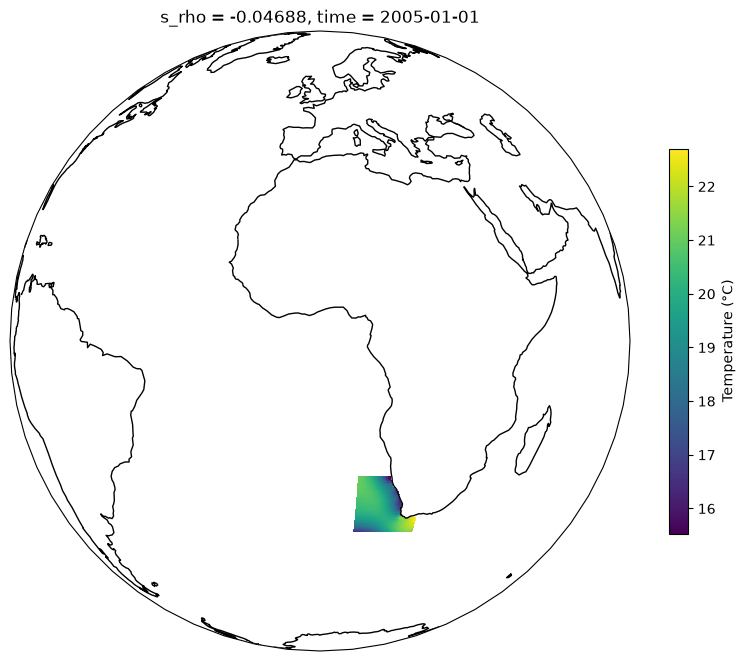

In [16]:

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(
    projection=ccrs.Orthographic(0,0))

ax.set_global()


croco.temp.isel(time=0, s_rho=30).where(croco.mask_rho != 0).plot(
    ax=ax,
    x="lon_rho",
    y="lat_rho",
    transform=ccrs.PlateCarree(), 
    cbar_kwargs={
        "shrink": 0.5,
        "label": "Temperature (°C)",
    },)  

ax.coastlines(resolution="110m", color="black", linewidth=1)

plt.show()

# In-situ data
CTD measurement taken from boat Meteo III, 'delayed-mode data', calbrated final product
- 4 main data variables of interest (and their associated quality flags): temperature, salinity, dissolved oxygen, chlorophylle mass concentration.

In [18]:
ctd = xr.open_dataset("./Datasets/insitu/met_098_1_ctd_034.nc")
ctd

<xarray.Dataset> Size: 230kB
Dimensions:       (PRES: 5105, TIME: 1, LATITUDE: 1, LONGITUDE: 1)
Coordinates:
  * PRES          (PRES) float64 41kB 4.0 5.0 6.0 ... 5.107e+03 5.108e+03
  * TIME          (TIME) datetime64[ns] 8B 2013-07-10T15:55:33.999999744
  * LATITUDE      (LATITUDE) float64 8B -11.5
  * LONGITUDE     (LONGITUDE) float64 8B -32.0
Data variables:
    PRES_QC       (PRES) int8 5kB ...
    TEMP          (PRES) float64 41kB ...
    TEMP_QC       (PRES) int8 5kB ...
    PSAL          (PRES) float64 41kB ...
    PSAL_QC       (PRES) int8 5kB ...
    DOX2          (PRES) float64 41kB ...
    DOX2_QC       (PRES) int8 5kB ...
    TIME_QC       (TIME) int8 1B ...
    LATITUDE_QC   (LATITUDE) int8 1B ...
    LONGITUDE_QC  (LONGITUDE) int8 1B ...
    FLU2          (PRES) float64 41kB ...
    FLU2_QC       (PRES) int8 5kB ...
Attributes: (12/81)
    Conventions:                                 CF-1.6, OceanSites Manual-1....
    netcdf_version:                              3.5
    GEOMAR_netcdf_version:                       6
    GEOMAR_po_svn_global_revision_when_writing:  258.0
    Conventions_comment:                         this file is not strict acco...
    Metadata_Conventions:                        Unidata Dataset Discovery v1.0
    ...                                          ...
    ship_name:                                   Meteor III
    station:                                     34
    ship_station:                                void
    water_depth:                                 5027.0
    cast:                                        1
    comment:

In [19]:
print(ctd.LATITUDE)
print(ctd.LONGITUDE)
print(ctd.TIME)

<xarray.DataArray 'LATITUDE' (LATITUDE: 1)> Size: 8B
array([-11.4998])
Coordinates:
  * LATITUDE  (LATITUDE) float64 8B -11.5
Attributes:
    long_name:      start or representative latitude
    standard_name:  latitude
    units:          degrees_north
    valid_min:      -11.4998
    valid_max:      -11.4998
    axis:           Y
<xarray.DataArray 'LONGITUDE' (LONGITUDE: 1)> Size: 8B
array([-32.0007])
Coordinates:
  * LONGITUDE  (LONGITUDE) float64 8B -32.0
Attributes:
    long_name:      start or representative longitude
    standard_name:  longitude
    units:          degrees_east
    valid_min:      -32.0007
    valid_max:      -32.0007
    axis:           X
<xarray.DataArray 'TIME' (TIME: 1)> Size: 8B
array(['2013-07-10T15:55:33.999999744'], dtype='datetime64[ns]')
Coordinates:
  * TIME     (TIME) datetime64[ns] 8B 2013-07-10T15:55:33.999999744
Attributes:
    long_name:  start or representative time
    comment:    add 712224.0 to time to get Matlab datenum equivalent
    valid

### Placing the point on the map

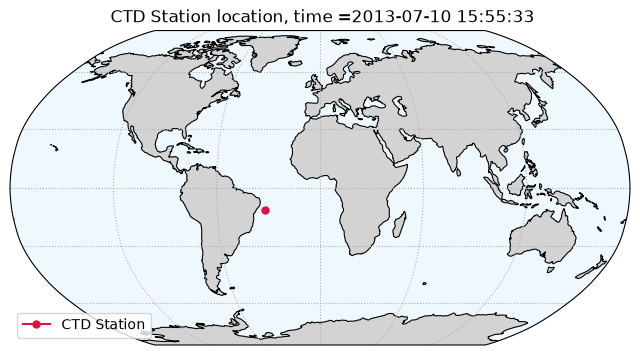

In [20]:
time = pd.to_datetime(ctd.TIME.values[0]).strftime('%Y-%m-%d %H:%M:%S')

fig = plt.figure(figsize=(8, 5))
# Robinson projection for full globe
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

# Add map layers
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.coastlines(linewidth=0.8)
ax.gridlines(linestyle=':')

ax.plot(ctd.LONGITUDE,ctd.LATITUDE, marker='o', color='crimson', markersize=5,
        transform=ccrs.PlateCarree(), label='CTD Station')

plt.title(' CTD Station location, time ='+str(time))
plt.legend(loc='lower left')
plt.show()

# Profiles
### Temperature & Salinity

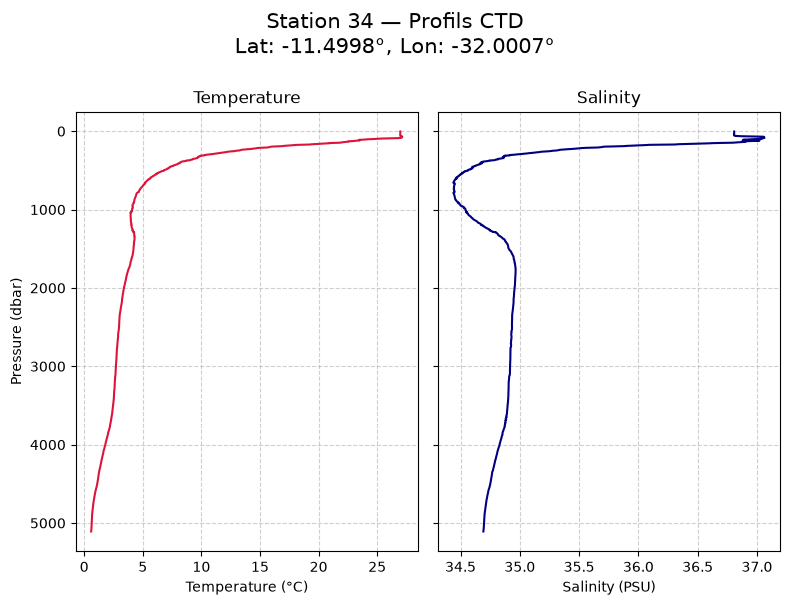

In [22]:
# Create 1 row, 2 columns of subplots sharing the same Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# Temperature Profile (Left Panel)
ax1.plot(ctd['TEMP'], ctd['PRES'], color='crimson', linewidth=1.5, label='Temperature')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Pressure (dbar)')
ax1.set_title('Temperature')
ax1.grid(True, linestyle='--', alpha=0.6)

# Salinity Profile (Right Panel)
ax2.plot(ctd['PSAL'], ctd['PRES'], color='navy', linewidth=1.5, label='Salinity')
ax2.set_xlabel('Salinity (PSU)')
ax2.set_title('Salinity')
ax2.grid(True, linestyle='--', alpha=0.6)

# Invert Y-axis (applying it to ax1 automatically inverts ax2 because sharey=True)
ax1.invert_yaxis()

#Main title
station_id = ctd.attrs.get('station', '')
lat_val = ctd.LATITUDE.values[0]
lon_val = ctd.LONGITUDE.values[0]

fig.suptitle(f"Station {station_id} — Profils CTD\nLat: {lat_val}°, Lon: {lon_val}°", 
             fontsize=15, y=1.0)

plt.tight_layout()
plt.show()

### Oxygen and Chlorophylle

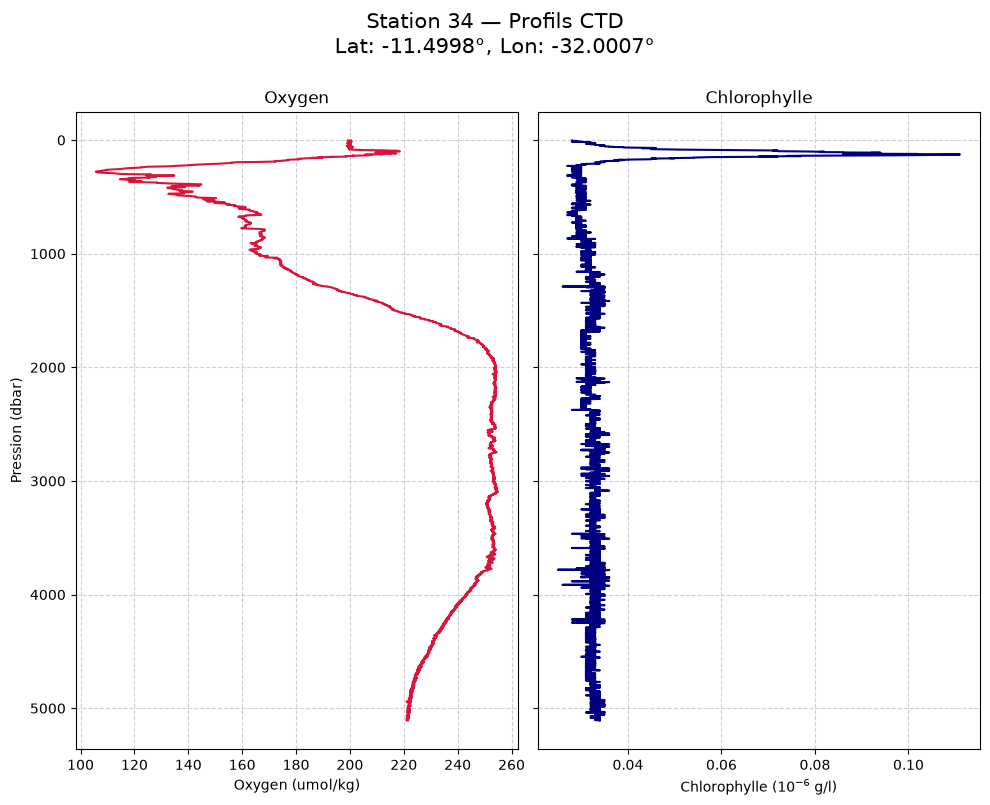

In [23]:
# Create 1 row, 2 columns of subplots sharing the same Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

# Oxygen Profile (Left Panel)
ax1.plot(ctd['DOX2'], ctd['PRES'], color='crimson', linewidth=1.5, label='Oxygen')
ax1.set_xlabel('Oxygen (umol/kg)')
ax1.set_ylabel('Pression (dbar)')
ax1.set_title('Oxygen')
ax1.grid(True, linestyle='--', alpha=0.6)

# Chrlorophylle Profile
ax2.plot(ctd['FLU2'], ctd['PRES'], color='navy', linewidth=1.5, label='Chlorophylle')
ax2.set_xlabel(r'Chlorophylle (10$^{-6}$ g/l)')
ax2.set_title('Chlorophylle')
ax2.grid(True, linestyle='--', alpha=0.6)

# Invert Y-axis (applying it to ax1 automatically inverts ax2 because sharey=True)
ax1.invert_yaxis()

#Main title
station_id = ctd.attrs.get('station', '')
lat_val = ctd.LATITUDE.values[0]
lon_val = ctd.LONGITUDE.values[0]

fig.suptitle(f"Station {station_id} — Profils CTD\nLat: {lat_val}°, Lon: {lon_val}°", 
             fontsize=15, y=1.0)

plt.tight_layout()
plt.show()

# Altimetry
Finally we open an altimety file, containing sea surface height in the Gulf of Guinea and associated variables, from SSALTO/DUACS between 10-16-2018 and 10-20-2018

2 types of sea level in the file:
- Sea surface height above geoid (Absolute dynamic topography)
- Sea level height above sea level (sea level anomaly, compared to [1993-2012] period)

In [24]:
altimetry = xr.open_dataset('./Datasets/altimetry/c3s_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.25deg_P1D_1789627939076.nc')

#Convert dates to strings for plots
date_str = altimetry.time.dt.strftime("%Y-%m-%d").values
altimetry


<xarray.Dataset> Size: 721kB
Dimensions:    (time: 5, latitude: 60, longitude: 100)
Coordinates:
  * time       (time) datetime64[ns] 40B 2018-10-16 2018-10-17 ... 2018-10-20
  * latitude   (latitude) float32 240B -4.875 -4.625 -4.375 ... 9.625 9.875
  * longitude  (longitude) float32 400B -9.875 -9.625 -9.375 ... 14.62 14.88
Data variables:
    adt        (time, latitude, longitude) float32 120kB ...
    sla        (time, latitude, longitude) float32 120kB ...
    ugos       (time, latitude, longitude) float32 120kB ...
    ugosa      (time, latitude, longitude) float32 120kB ...
    vgos       (time, latitude, longitude) float32 120kB ...
    vgosa      (time, latitude, longitude) float32 120kB ...
Attributes:
    Conventions:       CF-1.11
    title:             DT merged two satellites Global Ocean Gridded SSALTO/D...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2024/09/23 20:26:01 pva_axp@trex014.sis.cnes.fr Import...
    contact:           http://climate.copernicus.eu/c3s-user-service-desk
    references:        http://climate.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_CLIMATE_L4_MY_008_057
    subset:datasetId:  c3s_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.25deg_P1D_...
    subset:date:       2026-09-17T06:52:19.076Z

### Plot ADT vs SLA

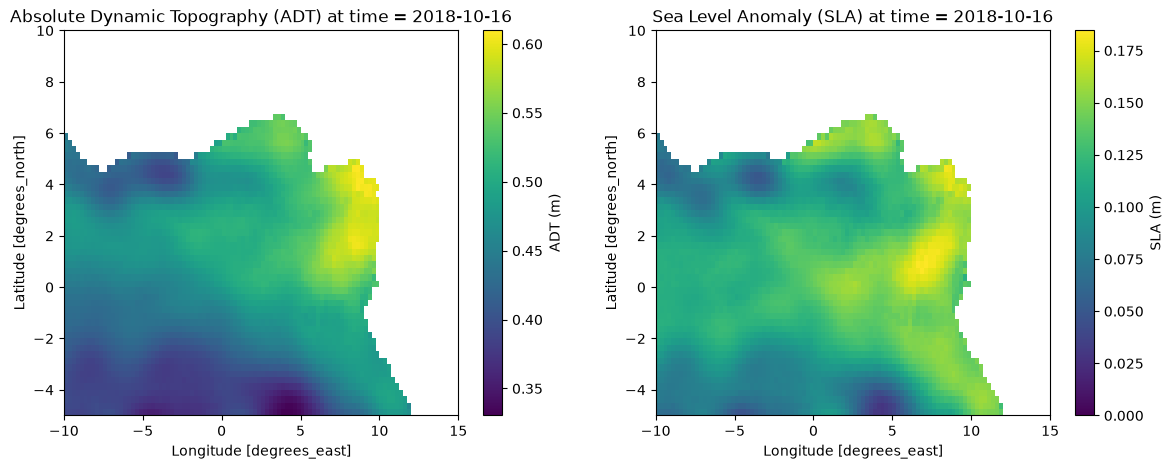

In [25]:
fig, axes = plt.subplots(1,2,figsize=(14, 5))

# Plot ADT
p1 = altimetry.adt.isel(time=0).plot(
    ax=axes[0],
    cbar_kwargs={"label": "ADT (m)"},
)

axes[0].set_title("Absolute Dynamic Topography (ADT) at time = "+date_str[0])

# Plot SLA
p2 = altimetry.sla.isel(time =0).plot(
    ax=axes[1],
    vmin=0,
    cbar_kwargs={"label": "SLA (m)"},
)
axes[1].set_title("Sea Level Anomaly (SLA) at time = "+ date_str[0])


plt.show()

### Plot Absolute velocities

Text(0.5, 1.0, 'Absolute velocities (ugos, vgos)\n2018-10-16')

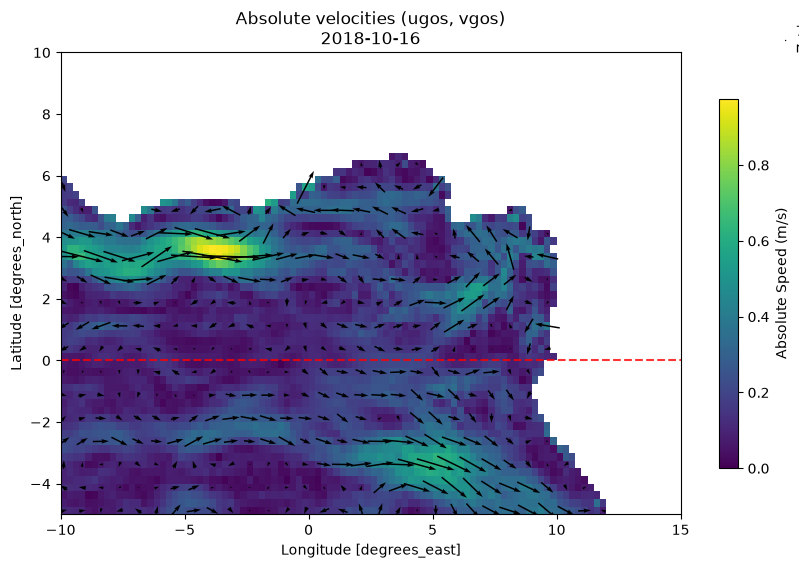

In [27]:
#Compute velocity modulus
speed = np.sqrt(altimetry.ugos.isel(time=0) ** 2 + altimetry.vgos.isel(time=0) ** 2)

fig, ax = plt.subplots(figsize=(10, 6))

#Plot velocity modulus
speed_plot = speed.plot(
    ax=ax,
    vmin=0,
    cbar_kwargs={"label": "Absolute Speed (m/s)", "shrink": 0.8},
)
ax.axhline(
    0, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Equator"
)
# Plot velocity vectors
step =3 #Only plot an arrow 1 every X cells, with X = step 
altimetry.isel(time=0).isel(latitude=slice(None, None, step), longitude=slice(None, None, step)
                           ).plot.quiver(x="longitude", y="latitude", u="ugos", v="vgos")
ax.set_title(
    f"Absolute velocities (ugos, vgos)\n{date_str[0]}"
)

### Plot Velocity anomalies
We can observe eddies!

Text(0.5, 1.0, 'Geostrophic Velocity Anomalies (ugosa, vgosa)\n2018-10-16')

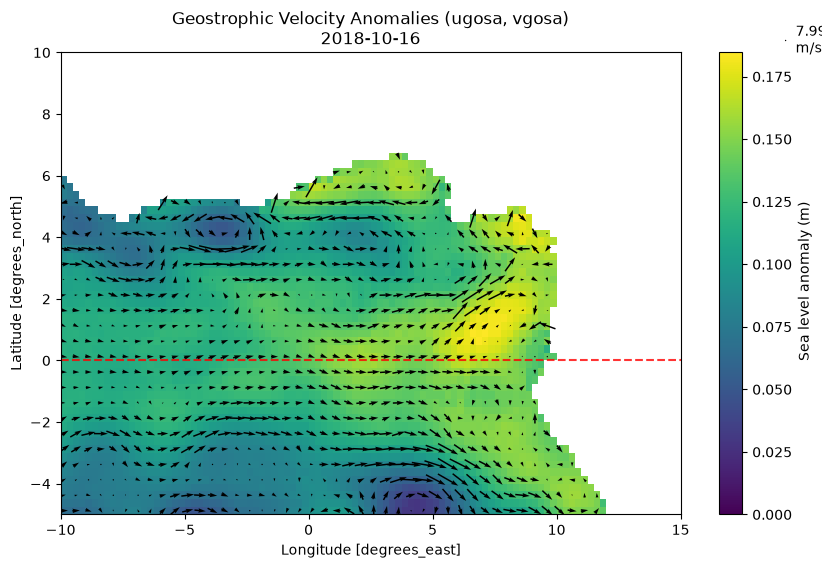

In [28]:
# Plot Sea level anomaly in background 
fig, ax = plt.subplots(figsize=(10, 6))
speed_plot = altimetry.sla.isel(time=0).plot(
    ax=ax,
    vmin=0,
    cbar_kwargs={"label": " Sea level anomaly (m)"},
)
# Plot velocity vectors
step =2 #Only plot an arrow 1 every X cells, with X = step 
altimetry.isel(time=0).isel(latitude=slice(None, None, step), longitude=slice(None, None, step)
                           ).plot.quiver(x="longitude", y="latitude", u="ugosa", v="vgosa")
ax.axhline(
    0, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Equator"
)
ax.set_title(
    f"Geostrophic Velocity Anomalies (ugosa, vgosa)\n{date_str[0]}"
)

- **Cyclonic Eddies**: Around low SLA, the eddies are **anti-clockwise** above Equator, and **clockwise** below.
- **Anticyclonic Eddies**: Around high SLA, the eddies are **clockwise** above Equator, and **anti-clockwise** below.                                      